# 03 - Supervised Classification: Crash Severity Prediction
**Owner:** Diyouva Novith

## Alignment Notes
- Core question: How well can we predict severe crash outcomes from crash-level features?
- Predicting tasks:
  - Track A: Predict `is_severe` from engineered crash-level features.
  - Track B: Predict condition-profile risk from aggregated profiles.
- Based on what data:
  - `dataset/cleaned_data/train_model.csv`, `test_model.csv` (from notebook 02)
  - `dataset/cleaned_data/train.csv`, `test.csv` (from notebook 01)
  - `dataset/cleaned_data/feature_columns.json` (feature contract from notebook 02)
- Outputs:
  - `dataset/cleaned_data/risk_scores.csv` for notebooks 04 and 05
  - Model evaluation tables and figures for paper
- Run-order dependency: `01 -> 02 -> 03 -> 04 -> 05`

---

In [52]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, f1_score, average_precision_score
)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

DATA_ROOT = Path('dataset') if Path('dataset').exists() else Path('../dataset')
CLEAN_DIR = DATA_ROOT / 'cleaned_data'
IMAGE_DIR = Path('image/03_classification') if Path('image').exists() or Path('notebooks').exists() else Path('../image/03_classification')
IMAGE_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(filename: str, dpi: int = 180) -> Path:
    out = IMAGE_DIR / filename
    plt.savefig(out, dpi=dpi, bbox_inches='tight')
    print('Saved figure:', out.resolve())
    return out


try:
    from IPython.display import display
except Exception:
    def display(obj):
        print(obj)

## 1) Data continuity contract (JSON + CSV)

In [53]:
required_inputs = {
    'train_model.csv': CLEAN_DIR / 'train_model.csv',
    'test_model.csv': CLEAN_DIR / 'test_model.csv',
    'train.csv': CLEAN_DIR / 'train.csv',
    'test.csv': CLEAN_DIR / 'test.csv',
    'feature_columns.json': CLEAN_DIR / 'feature_columns.json',
}

for name, path in required_inputs.items():
    status = 'exists' if path.exists() else 'MISSING'
    print(f'  {name}: {status}')
    assert path.exists(), f'Required input missing: {path}'

# Load feature contract
with open(CLEAN_DIR / 'feature_columns.json') as f:
    meta = json.load(f)

FEATURE_COLS = meta['feature_cols']
TARGET = meta['target']
print(f'\nFeature contract: {len(FEATURE_COLS)} features, target={TARGET}')

  train_model.csv: exists
  test_model.csv: exists
  train.csv: exists
  test.csv: exists
  feature_columns.json: exists

Feature contract: 101 features, target=is_severe


In [54]:
# Load engineered model data
train_model = pd.read_csv(CLEAN_DIR / 'train_model.csv')
test_model = pd.read_csv(CLEAN_DIR / 'test_model.csv')

# Enforce contract: feature_cols must be present
missing_train = set(FEATURE_COLS) - set(train_model.columns)
missing_test = set(FEATURE_COLS) - set(test_model.columns)
assert not missing_train, f'Missing in train_model: {missing_train}'
assert not missing_test, f'Missing in test_model: {missing_test}'

X_train = train_model[FEATURE_COLS]
y_train = train_model[TARGET]
X_test = test_model[FEATURE_COLS]
y_test = test_model[TARGET]

print(f'Train: {X_train.shape}, severe rate: {y_train.mean()*100:.2f}% ({y_train.sum()} / {len(y_train)})')
print(f'Test:  {X_test.shape}, severe rate: {y_test.mean()*100:.2f}% ({y_test.sum()} / {len(y_test)})')

Train: (246221, 101), severe rate: 1.65% (4056 / 246221)
Test:  (82274, 101), severe rate: 1.51% (1246 / 82274)


---
## 2) Track A — Crash-Level Classification

### 2.1 Handle class imbalance

In [55]:
# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SMOTE oversampling (30% minority ratio) for LR
smote = SMOTE(random_state=42, sampling_strategy=0.3)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f'Before SMOTE: {dict(pd.Series(y_train).value_counts())}')
print(f'After SMOTE:  {dict(pd.Series(y_train_smote).value_counts())}')

# scale_pos_weight for XGBoost
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f'\nscale_pos_weight for XGBoost: {scale_pos:.1f}')

Before SMOTE: {0: np.int64(242165), 1: np.int64(4056)}
After SMOTE:  {0: np.int64(242165), 1: np.int64(72649)}

scale_pos_weight for XGBoost: 59.7


### 2.2 Model training

In [56]:
results = {}

In [57]:
%%time
# --- Logistic Regression (baseline) ---
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, solver='lbfgs')
lr.fit(X_train_smote, y_train_smote)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

results['Logistic Regression'] = {'model': lr, 'y_pred': y_pred_lr, 'y_prob': y_prob_lr}

print('Logistic Regression (SMOTE + balanced)')
print(classification_report(y_test, y_pred_lr, target_names=['Non-Severe', 'Severe']))

Logistic Regression (SMOTE + balanced)
              precision    recall  f1-score   support

  Non-Severe       1.00      0.71      0.83     81028
      Severe       0.04      0.79      0.08      1246

    accuracy                           0.71     82274
   macro avg       0.52      0.75      0.45     82274
weighted avg       0.98      0.71      0.82     82274

CPU times: user 7.58 s, sys: 88.4 ms, total: 7.66 s
Wall time: 1.25 s


In [58]:
%%time
# --- Random Forest ---
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    max_depth=15,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

results['Random Forest'] = {'model': rf, 'y_pred': y_pred_rf, 'y_prob': y_prob_rf}

print('Random Forest (balanced class weights)')
print(classification_report(y_test, y_pred_rf, target_names=['Non-Severe', 'Severe']))

Random Forest (balanced class weights)
              precision    recall  f1-score   support

  Non-Severe       0.99      0.84      0.91     81028
      Severe       0.06      0.61      0.10      1246

    accuracy                           0.84     82274
   macro avg       0.52      0.73      0.51     82274
weighted avg       0.98      0.84      0.90     82274

CPU times: user 51.1 s, sys: 571 ms, total: 51.6 s
Wall time: 5.75 s


In [59]:
%%time
# --- XGBoost ---
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='aucpr',
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

results['XGBoost'] = {'model': xgb, 'y_pred': y_pred_xgb, 'y_prob': y_prob_xgb}

print('XGBoost (scale_pos_weight)')
print(classification_report(y_test, y_pred_xgb, target_names=['Non-Severe', 'Severe']))

XGBoost (scale_pos_weight)
              precision    recall  f1-score   support

  Non-Severe       0.99      0.83      0.90     81028
      Severe       0.05      0.62      0.10      1246

    accuracy                           0.82     82274
   macro avg       0.52      0.72      0.50     82274
weighted avg       0.98      0.82      0.89     82274

CPU times: user 11.4 s, sys: 844 ms, total: 12.3 s
Wall time: 2.36 s


### 2.3 Model evaluation

Saved figure: /Users/utami/CodeFolder/cmu-ml-midterm-project/image/03_classification/01_roc_pr_curves.png


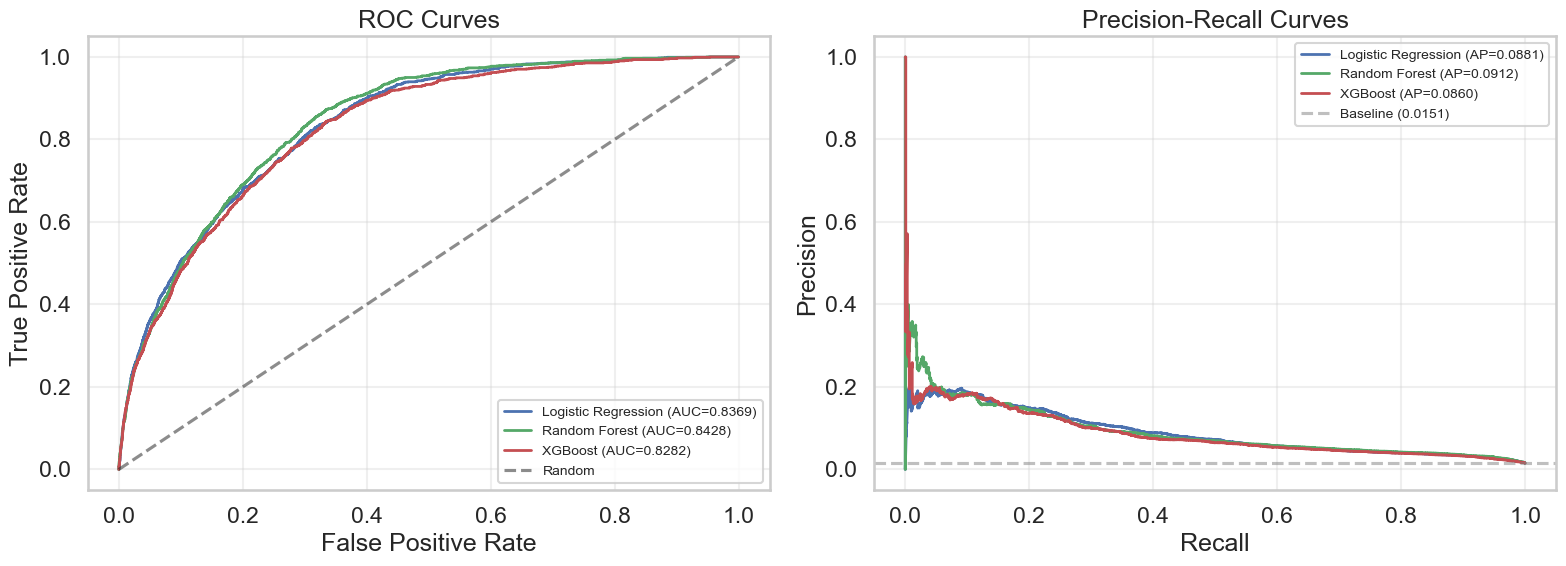

In [60]:
# --- ROC and Precision-Recall Curves ---
colors = {'Logistic Regression': '#4C72B0', 'Random Forest': '#55A868', 'XGBoost': '#C44E52'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    auc = roc_auc_score(y_test, res['y_prob'])
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})', color=colors[name], linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

for name, res in results.items():
    precision, recall, _ = precision_recall_curve(y_test, res['y_prob'])
    ap = average_precision_score(y_test, res['y_prob'])
    axes[1].plot(recall, precision, label=f'{name} (AP={ap:.4f})', color=colors[name], linewidth=2)

axes[1].axhline(y=y_test.mean(), color='gray', linestyle='--', alpha=0.5, label=f'Baseline ({y_test.mean():.4f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
save_fig('01_roc_pr_curves.png')
plt.show()

Saved figure: /Users/utami/CodeFolder/cmu-ml-midterm-project/image/03_classification/02_confusion_matrices.png


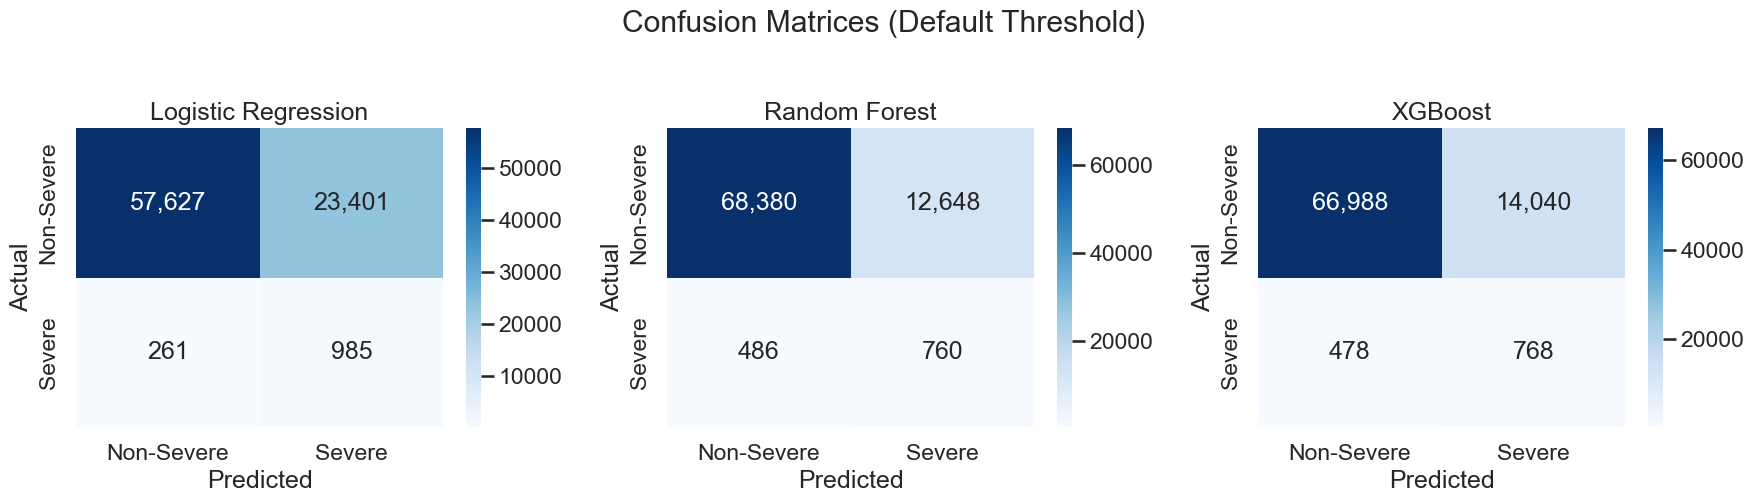

In [61]:
# --- Confusion Matrices ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax,
                xticklabels=['Non-Severe', 'Severe'],
                yticklabels=['Non-Severe', 'Severe'])
    ax.set_title(name)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices (Default Threshold)', y=1.02)
plt.tight_layout()
save_fig('02_confusion_matrices.png')
plt.show()

Saved figure: /Users/utami/CodeFolder/cmu-ml-midterm-project/image/03_classification/03_threshold_analysis.png


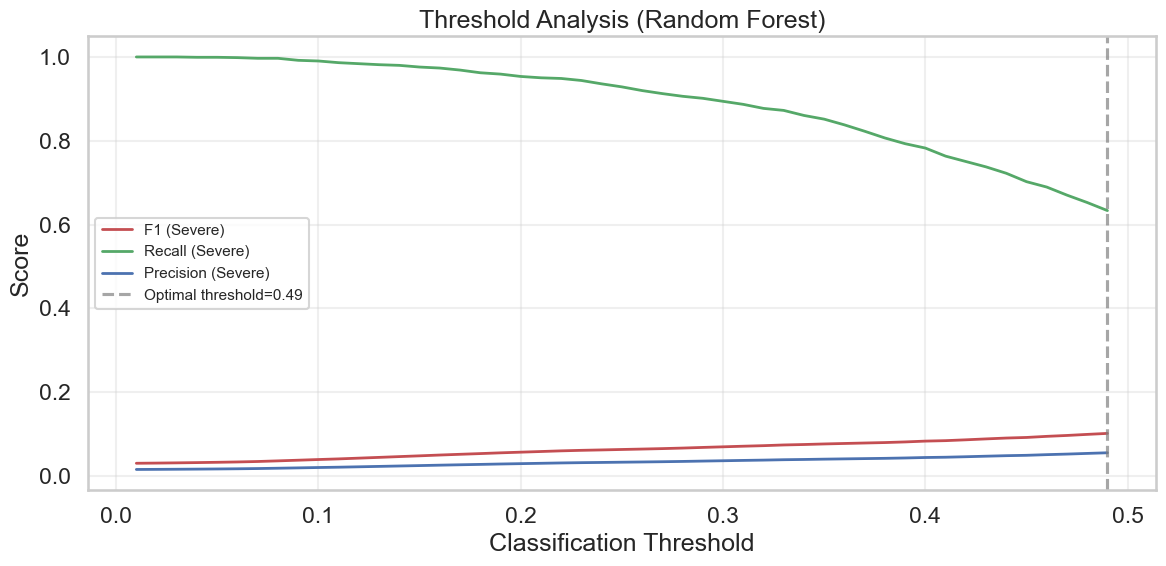


Optimal threshold for Random Forest: 0.49
  F1:        0.1013
  Recall:    0.6332
  Precision: 0.0551


In [62]:
# --- Threshold Analysis ---
best_model_name = max(results.keys(), key=lambda k: roc_auc_score(y_test, results[k]['y_prob']))
best_probs = results[best_model_name]['y_prob']

thresholds = np.arange(0.01, 0.50, 0.01)
f1_scores, recall_scores, precision_scores = [], [], []

for t in thresholds:
    y_pred_t = (best_probs >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    tp, fp, fn = cm[1, 1], cm[0, 1], cm[1, 0]
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    f1_scores.append(f1)
    recall_scores.append(rec)
    precision_scores.append(prec)

optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(thresholds, f1_scores, label='F1 (Severe)', linewidth=2, color='#C44E52')
ax.plot(thresholds, recall_scores, label='Recall (Severe)', linewidth=2, color='#55A868')
ax.plot(thresholds, precision_scores, label='Precision (Severe)', linewidth=2, color='#4C72B0')
ax.axvline(x=optimal_threshold, color='gray', linestyle='--', alpha=0.7,
           label=f'Optimal threshold={optimal_threshold:.2f}')
ax.set_xlabel('Classification Threshold')
ax.set_ylabel('Score')
ax.set_title(f'Threshold Analysis ({best_model_name})')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
save_fig('03_threshold_analysis.png')
plt.show()

print(f'\nOptimal threshold for {best_model_name}: {optimal_threshold:.2f}')
print(f'  F1:        {f1_scores[optimal_idx]:.4f}')
print(f'  Recall:    {recall_scores[optimal_idx]:.4f}')
print(f'  Precision: {precision_scores[optimal_idx]:.4f}')

Random Forest with optimal threshold (0.49):
              precision    recall  f1-score   support

  Non-Severe       0.99      0.83      0.91     81028
      Severe       0.06      0.63      0.10      1246

    accuracy                           0.83     82274
   macro avg       0.52      0.73      0.50     82274
weighted avg       0.98      0.83      0.89     82274

Saved figure: /Users/utami/CodeFolder/cmu-ml-midterm-project/image/03_classification/04_cm_optimal_threshold.png


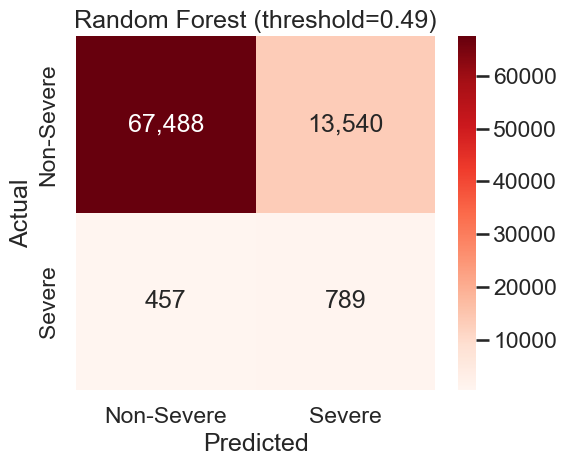

In [63]:
# --- Evaluation with Optimal Threshold ---
y_pred_optimal = (best_probs >= optimal_threshold).astype(int)

print(f'{best_model_name} with optimal threshold ({optimal_threshold:.2f}):')
print(classification_report(y_test, y_pred_optimal, target_names=['Non-Severe', 'Severe']))

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_optimal)
sns.heatmap(cm, annot=True, fmt=',d', cmap='Reds', ax=ax,
            xticklabels=['Non-Severe', 'Severe'],
            yticklabels=['Non-Severe', 'Severe'])
ax.set_title(f'{best_model_name} (threshold={optimal_threshold:.2f})')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')

plt.tight_layout()
save_fig('04_cm_optimal_threshold.png')
plt.show()

### 2.4 Feature importance

Saved figure: /Users/utami/CodeFolder/cmu-ml-midterm-project/image/03_classification/05_rf_feature_importance.png


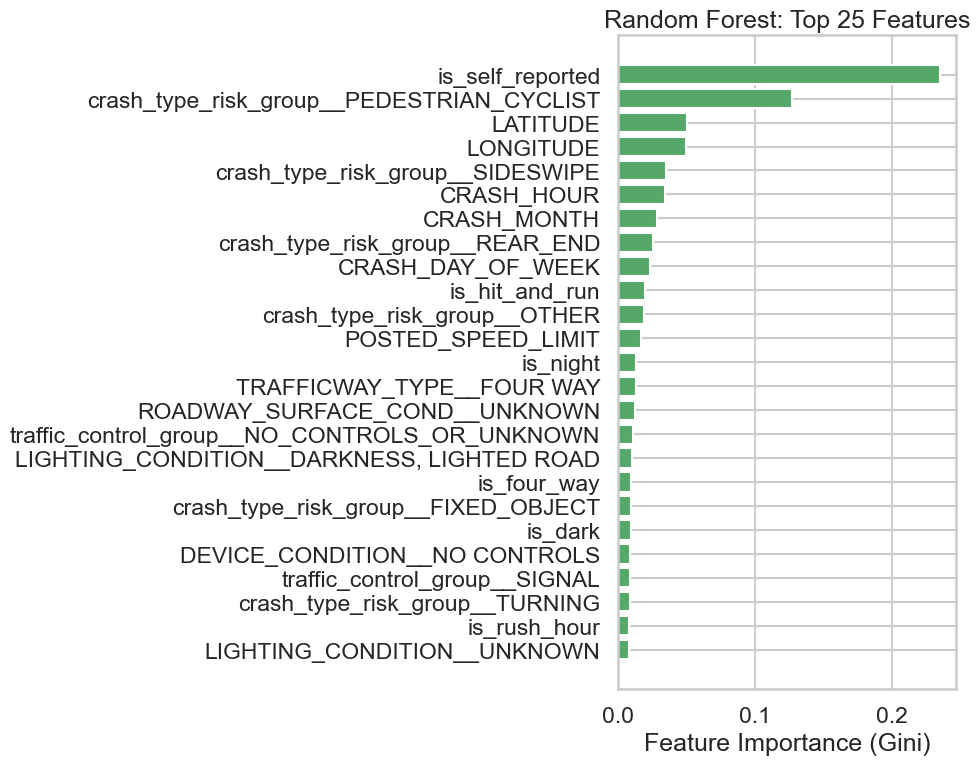

In [64]:
# --- Random Forest Feature Importance ---
top_n = 25

rf_imp = pd.DataFrame({'feature': FEATURE_COLS, 'importance': rf.feature_importances_})
rf_imp = rf_imp.sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(rf_imp.tail(top_n)['feature'], rf_imp.tail(top_n)['importance'], color='#55A868')
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title(f'Random Forest: Top {top_n} Features')
plt.tight_layout()
save_fig('05_rf_feature_importance.png')
plt.show()

Saved figure: /Users/utami/CodeFolder/cmu-ml-midterm-project/image/03_classification/06_xgb_feature_importance.png


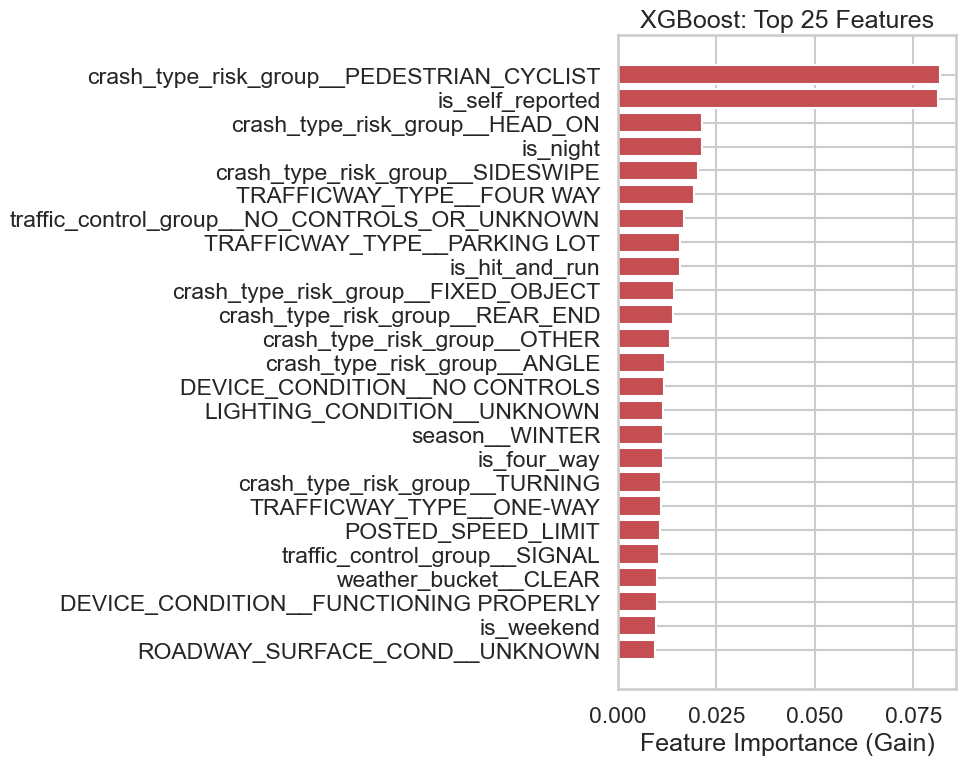

In [65]:
# --- XGBoost Feature Importance ---
xgb_imp = pd.DataFrame({'feature': FEATURE_COLS, 'importance': xgb.feature_importances_})
xgb_imp = xgb_imp.sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(xgb_imp.tail(top_n)['feature'], xgb_imp.tail(top_n)['importance'], color='#C44E52')
ax.set_xlabel('Feature Importance (Gain)')
ax.set_title(f'XGBoost: Top {top_n} Features')
plt.tight_layout()
save_fig('06_xgb_feature_importance.png')
plt.show()

Saved figure: /Users/utami/CodeFolder/cmu-ml-midterm-project/image/03_classification/07_lr_coefficients.png


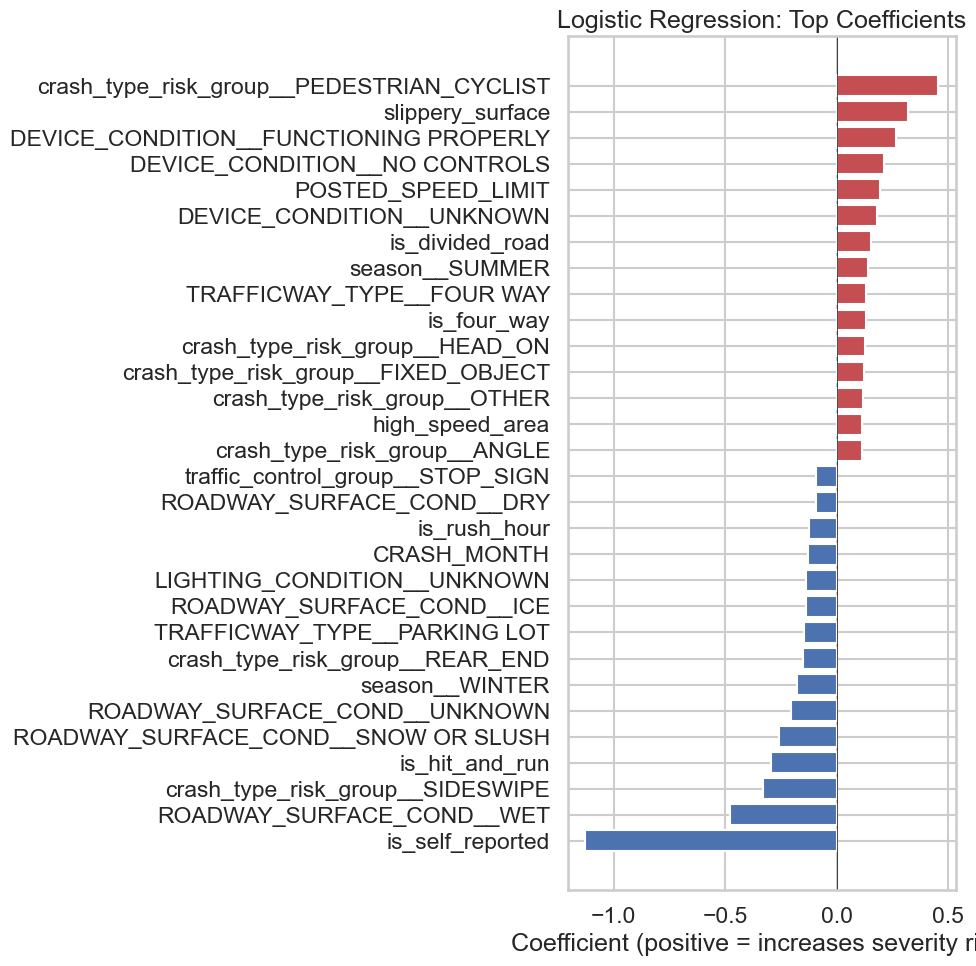

In [66]:
# --- Logistic Regression Coefficients ---
lr_coefs = pd.DataFrame({'feature': FEATURE_COLS, 'coefficient': lr.coef_[0]})
lr_coefs = lr_coefs.sort_values('coefficient')

top_pos = lr_coefs.tail(15)
top_neg = lr_coefs.head(15)
lr_display = pd.concat([top_neg, top_pos])

fig, ax = plt.subplots(figsize=(10, 10))
colors_lr = ['#C44E52' if c > 0 else '#4C72B0' for c in lr_display['coefficient']]
ax.barh(lr_display['feature'], lr_display['coefficient'], color=colors_lr)
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_xlabel('Coefficient (positive = increases severity risk)')
ax.set_title('Logistic Regression: Top Coefficients')
plt.tight_layout()
save_fig('07_lr_coefficients.png')
plt.show()

In [67]:
# --- Cross-model feature importance overlap ---
rf_top15 = set(rf_imp.tail(15)['feature'])
xgb_top15 = set(xgb_imp.tail(15)['feature'])
common = rf_top15 & xgb_top15

print(f'Top-15 feature overlap between RF and XGBoost:')
print(f'  Common ({len(common)}): {sorted(common)}')
print(f'  RF only ({len(rf_top15 - xgb_top15)}): {sorted(rf_top15 - xgb_top15)}')
print(f'  XGBoost only ({len(xgb_top15 - rf_top15)}): {sorted(xgb_top15 - rf_top15)}')

Top-15 feature overlap between RF and XGBoost:
  Common (8): ['TRAFFICWAY_TYPE__FOUR WAY', 'crash_type_risk_group__OTHER', 'crash_type_risk_group__PEDESTRIAN_CYCLIST', 'crash_type_risk_group__REAR_END', 'crash_type_risk_group__SIDESWIPE', 'is_hit_and_run', 'is_night', 'is_self_reported']
  RF only (7): ['CRASH_DAY_OF_WEEK', 'CRASH_HOUR', 'CRASH_MONTH', 'LATITUDE', 'LONGITUDE', 'POSTED_SPEED_LIMIT', 'ROADWAY_SURFACE_COND__UNKNOWN']
  XGBoost only (7): ['DEVICE_CONDITION__NO CONTROLS', 'LIGHTING_CONDITION__UNKNOWN', 'TRAFFICWAY_TYPE__PARKING LOT', 'crash_type_risk_group__ANGLE', 'crash_type_risk_group__FIXED_OBJECT', 'crash_type_risk_group__HEAD_ON', 'traffic_control_group__NO_CONTROLS_OR_UNKNOWN']


### 2.5 Track A Summary

In [68]:
summary_rows = []
for name, res in results.items():
    report = classification_report(y_test, res['y_pred'], labels=[0, 1], target_names=['Non-Severe', 'Severe'], zero_division=0, output_dict=True)
    auc = roc_auc_score(y_test, res['y_prob'])
    ap = average_precision_score(y_test, res['y_prob'])
    summary_rows.append({
        'Model': name,
        'Precision (Severe)': f"{report['Severe']['precision']:.4f}",
        'Recall (Severe)': f"{report['Severe']['recall']:.4f}",
        'F1 (Severe)': f"{report['Severe']['f1-score']:.4f}",
        'AUC-ROC': f'{auc:.4f}',
        'Avg Precision': f'{ap:.4f}'
    })

summary_df = pd.DataFrame(summary_rows)
print('=' * 90)
print('TRACK A: CRASH-LEVEL MODEL COMPARISON')
print('=' * 90)
display(summary_df)
print('=' * 90)
print(f'\nBest model by AUC-ROC: {best_model_name}')
print(f'Optimal threshold: {optimal_threshold:.2f}')
print(f'At optimal threshold - Recall: {recall_scores[optimal_idx]:.4f}, Precision: {precision_scores[optimal_idx]:.4f}, F1: {f1_scores[optimal_idx]:.4f}')

TRACK A: CRASH-LEVEL MODEL COMPARISON


,Model,Precision (Severe),Recall (Severe),F1 (Severe),AUC-ROC,Avg Precision
0,Logistic Regression,0.0404,0.7905,0.0769,0.8369,0.0881
1,Random Forest,0.0567,0.6100,0.1037,0.8428,0.0912
2,XGBoost,0.0519,0.6164,0.0957,0.8282,0.0860



Best model by AUC-ROC: Random Forest
Optimal threshold: 0.49
At optimal threshold - Recall: 0.6332, Precision: 0.0551, F1: 0.1013


Saved figure: /Users/utami/CodeFolder/cmu-ml-midterm-project/image/03_classification/08_model_comparison.png


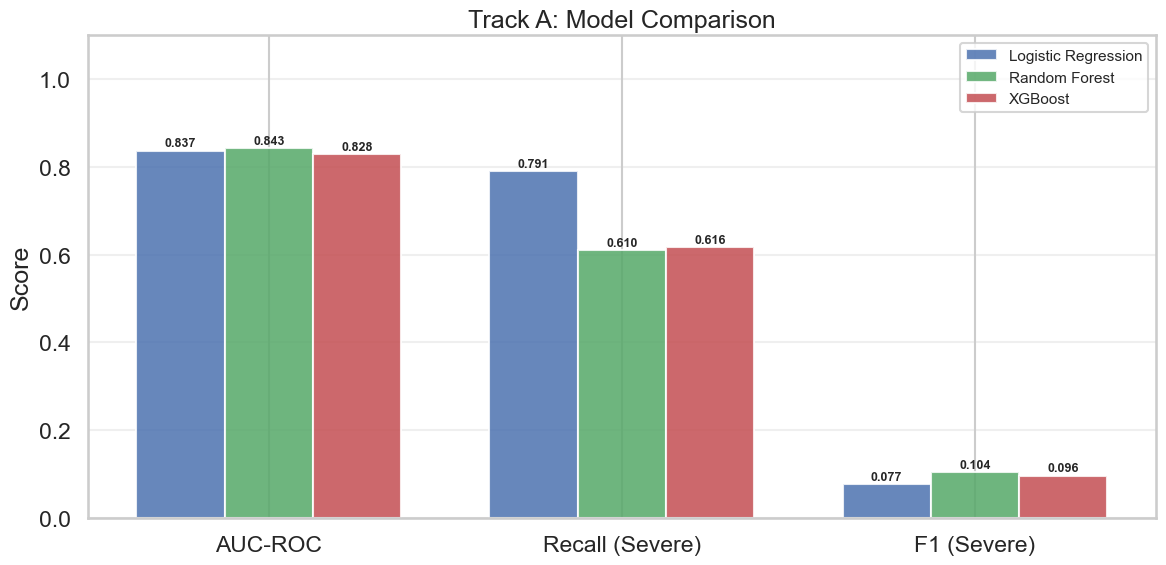

In [69]:
# Visual comparison
fig, ax = plt.subplots(figsize=(12, 6))

models = list(results.keys())
metrics_names = ['AUC-ROC', 'Recall (Severe)', 'F1 (Severe)']

metric_values = {}
for name, res in results.items():
    report = classification_report(y_test, res['y_pred'], labels=[0, 1], target_names=['Non-Severe', 'Severe'], zero_division=0, output_dict=True)
    metric_values[name] = [
        roc_auc_score(y_test, res['y_prob']),
        report['Severe']['recall'],
        report['Severe']['f1-score']
    ]

x = np.arange(len(metrics_names))
width = 0.25

for i, (name, vals) in enumerate(metric_values.items()):
    bars = ax.bar(x + i * width, vals, width, label=name,
                  color=list(colors.values())[i], alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_names)
ax.set_ylabel('Score')
ax.set_title('Track A: Model Comparison')
ax.legend(fontsize=11)
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
save_fig('08_model_comparison.png')
plt.show()

---
## 3) Track B — Condition-Level Risk Model

Aggregate crash data to condition profiles and rank risk for CDOT prioritization.

In [70]:
# Load base train/test for aggregation
train_base = pd.read_csv(CLEAN_DIR / 'train.csv')
test_base = pd.read_csv(CLEAN_DIR / 'test.csv')
train_base['CRASH_DATE'] = pd.to_datetime(train_base['CRASH_DATE'], errors='coerce')
test_base['CRASH_DATE'] = pd.to_datetime(test_base['CRASH_DATE'], errors='coerce')

# Combine for profile building (use full data for stable profiles)
all_base = pd.concat([train_base, test_base], ignore_index=True)

print(f'Combined base data: {len(all_base)} rows')

Combined base data: 328495 rows


In [71]:
# Build condition profiles
profile = all_base.copy()
profile = profile.dropna(subset=['LATITUDE', 'LONGITUDE'])

# Grid cells (~500m)
profile['grid_lat'] = (pd.to_numeric(profile['LATITUDE'], errors='coerce') / 0.005).round() * 0.005
profile['grid_lon'] = (pd.to_numeric(profile['LONGITUDE'], errors='coerce') / 0.005).round() * 0.005

# Weather bucket
weather_u = profile['WEATHER_CONDITION'].fillna('UNKNOWN').astype(str).str.upper()
profile['weather_bucket'] = np.select(
    [weather_u.str.contains('CLEAR'), weather_u.str.contains('RAIN|DRIZZLE'),
     weather_u.str.contains('SNOW|SLEET|ICE|FREEZING')],
    ['CLEAR', 'RAIN', 'SNOW_ICE'], default='OTHER')

# Lighting bucket
lighting_u = profile['LIGHTING_CONDITION'].fillna('UNKNOWN').astype(str).str.upper()
profile['lighting_bucket'] = np.select(
    [lighting_u.str.contains('DAYLIGHT'), lighting_u.str.contains('DARKNESS, LIGHTED'),
     lighting_u.str.contains('DARKNESS') & ~lighting_u.str.contains('LIGHTED'),
     lighting_u.str.contains('DAWN|DUSK')],
    ['DAYLIGHT', 'DARK_LIT', 'DARK_UNLIT', 'DAWN_DUSK'], default='OTHER')

# Time bucket
hour = pd.to_numeric(profile['CRASH_HOUR'], errors='coerce').fillna(12)
dow = pd.to_numeric(profile['CRASH_DAY_OF_WEEK'], errors='coerce').fillna(2)
profile['time_bucket'] = np.select(
    [dow.isin([1, 7]), hour.isin([7,8,9,16,17,18]),
     hour.isin([20,21,22,23,0,1,2,3,4,5])],
    ['WEEKEND', 'RUSH_HOUR', 'NIGHT'], default='DAYTIME')

# Speed bucket
speed = pd.to_numeric(profile['POSTED_SPEED_LIMIT'], errors='coerce').fillna(30)
profile['speed_bucket'] = pd.cut(speed, bins=[-1, 25, 30, 35, 45, 100],
                                  labels=['<=25', '26-30', '31-35', '36-45', '46+']).astype(str)

# Aggregate
agg_cols = ['grid_lat', 'grid_lon', 'weather_bucket', 'lighting_bucket', 'time_bucket', 'speed_bucket']
agg = (profile.groupby(agg_cols, as_index=False)
       .agg(crash_count=('is_severe', 'size'),
            severe_count=('is_severe', 'sum'),
            severe_rate=('is_severe', 'mean')))

print(f'Total condition profiles: {len(agg)}')
print(f'Profiles with >=10 crashes: {(agg["crash_count"] >= 10).sum()}')

Total condition profiles: 91085
Profiles with >=10 crashes: 6740


In [72]:
# Empirical-Bayes shrinkage for stable ranking
global_rate = profile['is_severe'].mean()
alpha = 30  # shrinkage strength

agg['predicted_severe_rate'] = (agg['severe_count'] + alpha * global_rate) / (agg['crash_count'] + alpha)
agg['has_severe'] = (agg['severe_count'] > 0).astype(int)

# Risk score = shrunk rate * log(crash_count + 1) to weight both rate and volume
agg['risk_score'] = agg['predicted_severe_rate'] * np.log1p(agg['crash_count'])

# Rank
agg = agg.sort_values('risk_score', ascending=False).reset_index(drop=True)
agg['rank'] = range(1, len(agg) + 1)

# Recommendation
def assign_recommendation(row):
    if row['rank'] <= 50:
        return 'PRIORITY: Immediate infrastructure review + targeted enforcement'
    elif row['rank'] <= 200:
        return 'HIGH: Schedule safety audit and consider countermeasures'
    elif row['rank'] <= 500:
        return 'MODERATE: Monitor and include in next planning cycle'
    else:
        return 'STANDARD: Routine monitoring'

agg['recommendation'] = agg.apply(assign_recommendation, axis=1)

print('Risk score distribution:')
display(agg[['risk_score', 'crash_count', 'severe_rate', 'predicted_severe_rate', 'rank']].describe())

print(f'\nTop 10 highest-risk profiles:')
display(agg.head(10)[['grid_lat', 'grid_lon', 'weather_bucket', 'lighting_bucket',
                       'time_bucket', 'speed_bucket', 'crash_count', 'severe_count',
                       'severe_rate', 'predicted_severe_rate', 'risk_score', 'rank', 'recommendation']])

Risk score distribution:


,risk_score,crash_count,severe_rate,predicted_severe_rate,rank
count,91085.000000,91085.000000,91085.000000,91085.000000,91085.000000
mean,0.018444,3.600362,0.016137,0.016161,45543.000000
std,0.016339,7.729211,0.104204,0.006087,26294.118972
min,0.010827,1.000000,0.000000,0.002421,1.000000
25%,0.010827,1.000000,0.000000,0.015132,22772.000000
50%,0.010827,1.000000,0.000000,0.015620,45543.000000
75%,0.020341,3.000000,0.000000,0.015620,68314.000000
max,0.276190,202.000000,1.000000,0.102477,91085.000000



Top 10 highest-risk profiles:


,grid_lat,grid_lon,weather_bucket,lighting_bucket,time_bucket,speed_bucket,crash_count,severe_count,severe_rate,predicted_severe_rate,risk_score,rank,recommendation
0,41.810,-87.745,CLEAR,DARK_LIT,WEEKEND,26-30,16,4,0.250000,0.097483,0.276190,1,PRIORITY: Immediate infrastructure review + ta...
1,41.885,-87.640,CLEAR,DARK_LIT,NIGHT,26-30,29,4,0.137931,0.076004,0.258503,2,PRIORITY: Immediate infrastructure review + ta...
2,41.890,-87.620,CLEAR,DAYLIGHT,WEEKEND,26-30,56,5,0.089286,0.063770,0.257825,3,PRIORITY: Immediate infrastructure review + ta...
3,41.795,-87.630,CLEAR,DARK_LIT,WEEKEND,26-30,34,4,0.117647,0.070066,0.249108,4,PRIORITY: Immediate infrastructure review + ta...
4,41.825,-87.685,CLEAR,DARK_LIT,WEEKEND,26-30,34,4,0.117647,0.070066,0.249108,5,PRIORITY: Immediate infrastructure review + ta...
5,41.885,-87.745,CLEAR,DAYLIGHT,DAYTIME,26-30,65,5,0.076923,0.057729,0.241863,6,PRIORITY: Immediate infrastructure review + ta...
6,41.795,-87.620,CLEAR,DAYLIGHT,DAYTIME,26-30,40,4,0.100000,0.064060,0.237892,7,PRIORITY: Immediate infrastructure review + ta...
7,41.735,-87.605,CLEAR,DAYLIGHT,RUSH_HOUR,26-30,48,4,0.083333,0.057490,0.223740,8,PRIORITY: Immediate infrastructure review + ta...
8,41.875,-87.720,CLEAR,DARK_LIT,WEEKEND,26-30,49,4,0.081633,0.056762,0.222055,9,PRIORITY: Immediate infrastructure review + ta...
9,41.765,-87.575,CLEAR,DAYLIGHT,DAYTIME,<=25,14,3,0.214286,0.079187,0.214441,10,PRIORITY: Immediate infrastructure review + ta...


Saved figure: /Users/utami/CodeFolder/cmu-ml-midterm-project/image/03_classification/09_top_risk_profiles.png


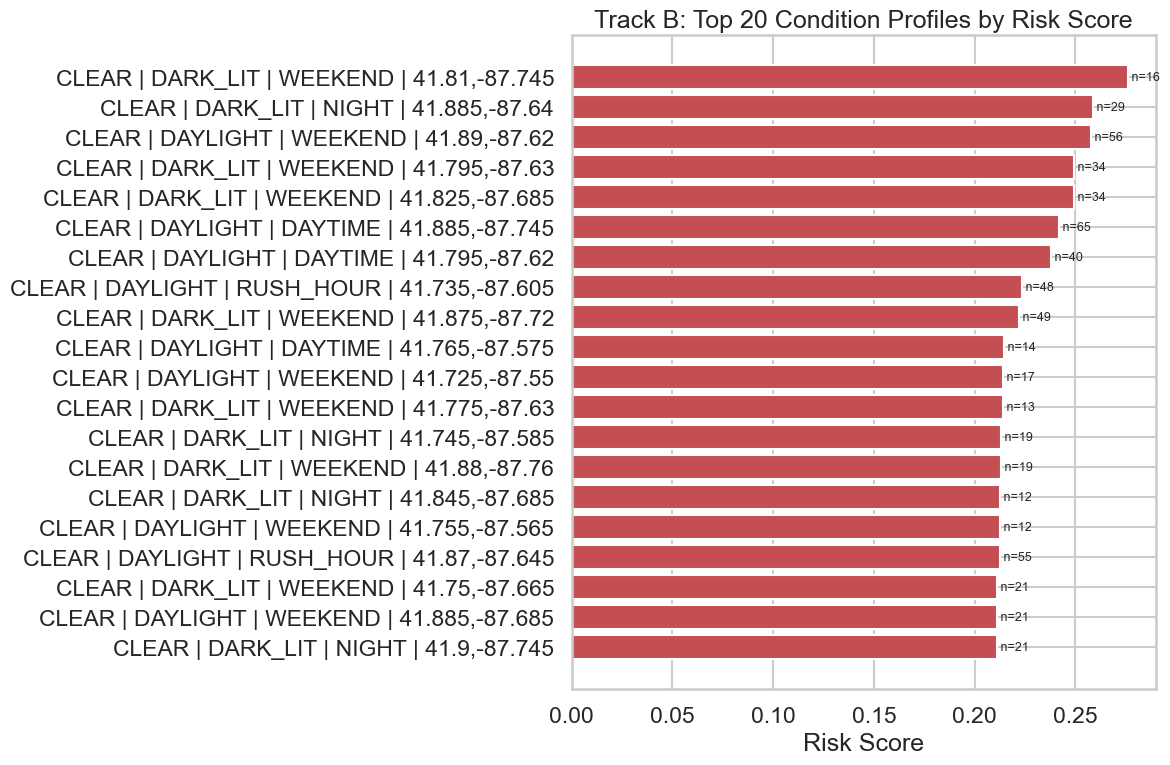

In [73]:
# Visualize top risk profiles
top_profiles = agg.head(20).copy()
top_profiles['label'] = (
    top_profiles['weather_bucket'] + ' | ' +
    top_profiles['lighting_bucket'] + ' | ' +
    top_profiles['time_bucket'] + ' | ' +
    top_profiles['grid_lat'].round(3).astype(str) + ',' +
    top_profiles['grid_lon'].round(3).astype(str)
)

plot_df = top_profiles.sort_values('risk_score', ascending=True)
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(plot_df['label'], plot_df['risk_score'], color='#C44E52')
for bar, n in zip(bars, plot_df['crash_count']):
    ax.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
            f' n={int(n)}', va='center', fontsize=9)
ax.set_xlabel('Risk Score')
ax.set_title('Track B: Top 20 Condition Profiles by Risk Score')
plt.tight_layout()
save_fig('09_top_risk_profiles.png')
plt.show()

In [74]:
# Save risk_scores.csv for notebooks 04 and 05
risk_output_cols = [
    'grid_lat', 'grid_lon',
    'weather_bucket', 'lighting_bucket', 'time_bucket', 'speed_bucket',
    'crash_count', 'severe_count', 'severe_rate',
    'predicted_severe_rate', 'risk_score', 'rank', 'recommendation'
]

risk_scores_path = CLEAN_DIR / 'risk_scores.csv'
agg[risk_output_cols].to_csv(risk_scores_path, index=False)

print(f'Saved: {risk_scores_path.resolve()}')
print(f'  Rows: {len(agg)}')
print(f'  Size: {risk_scores_path.stat().st_size / 1024:.1f} KB')
print(f'  Columns: {risk_output_cols}')

Saved: /Users/utami/CodeFolder/cmu-ml-midterm-project/dataset/cleaned_data/risk_scores.csv
  Rows: 91085
  Size: 11644.4 KB
  Columns: ['grid_lat', 'grid_lon', 'weather_bucket', 'lighting_bucket', 'time_bucket', 'speed_bucket', 'crash_count', 'severe_count', 'severe_rate', 'predicted_severe_rate', 'risk_score', 'rank', 'recommendation']


---
## 4) Handoff summary

In [75]:
print('=' * 70)
print('NOTEBOOK 03 OUTPUTS')
print('=' * 70)
print(f'''
Track A (Crash-Level Classification):
  Best model: {best_model_name}
  AUC-ROC: {roc_auc_score(y_test, results[best_model_name]["y_prob"]):.4f}
  Optimal threshold: {optimal_threshold:.2f}
  At optimal threshold:
    Recall:    {recall_scores[optimal_idx]:.4f}
    Precision: {precision_scores[optimal_idx]:.4f}
    F1:        {f1_scores[optimal_idx]:.4f}

Track B (Condition-Level Risk):
  Total profiles: {len(agg)}
  Priority profiles (rank<=50): {(agg["rank"] <= 50).sum()}
  High-risk profiles (rank<=200): {(agg["rank"] <= 200).sum()}
  Output: risk_scores.csv

Figures saved to: {IMAGE_DIR.resolve()}

Handoff to downstream notebooks:
  - 04_clustering.ipynb: reads train.csv for spatial clustering
  - 05_spatial_dashboard.ipynb: reads train.csv + risk_scores.csv + cluster_labels.csv
''')

NOTEBOOK 03 OUTPUTS

Track A (Crash-Level Classification):
  Best model: Random Forest
  AUC-ROC: 0.8428
  Optimal threshold: 0.49
  At optimal threshold:
    Recall:    0.6332
    Precision: 0.0551
    F1:        0.1013

Track B (Condition-Level Risk):
  Total profiles: 91085
  Priority profiles (rank<=50): 50
  High-risk profiles (rank<=200): 200
  Output: risk_scores.csv

Figures saved to: /Users/utami/CodeFolder/cmu-ml-midterm-project/image/03_classification

Handoff to downstream notebooks:
  - 04_clustering.ipynb: reads train.csv for spatial clustering
  - 05_spatial_dashboard.ipynb: reads train.csv + risk_scores.csv + cluster_labels.csv



### Handoff checklist

- `risk_scores.csv` exists in `dataset/cleaned_data/`
- `risk_scores.csv` contains all required columns
- `grid_lat` and `grid_lon` use the same 0.005-degree grid as notebook 04
- `rank` is unique and sorted by descending `risk_score`
- `recommendation` field is non-empty for all profiles